In [1]:
import os
import sys
import logging
import json
from mpi4py import MPI

from graphufs.datasets import Dataset
from graphufs.tensorstore import PackedDataset as TSPackedDataset, MPIBatchLoader as TSBatchLoader
from graphufs.mpi import MPITopology

from graphufs.stacked_mpi_training import (
    init_model,
    optimize,
)

from graphufs.optim import clipped_cosine_adamw
from graphufs.utils import get_last_input_mapping
from graphufs.stacked_utils import get_channel_index

In [2]:
from prototypes.ocn_only.R4.config import (
    OcnTrainer as RemoteEmulator,
    OcnPreprocessed as PackedEmulator,
)

In [3]:
topo = MPITopology(log_dir=f"{RemoteEmulator.local_store_path}/logs/training")

In [4]:
emulator = PackedEmulator(mpi_rank=topo.rank, mpi_size=topo.size)
remote_emulator = RemoteEmulator(mpi_rank=topo.rank, mpi_size=topo.size)

In [5]:
# data generators
tds = Dataset(remote_emulator, mode="training")

In [6]:
 # get the training and target meta data
logging.info("Getting metadata for inputs and targets")
xinputs, xtargets, xforcing = tds.get_xarrays(0)
meta_xinputs = get_channel_index(xinputs)
meta_xtargets = get_channel_index(xtargets)
meta_xforcing = get_channel_index(xforcing)

In [7]:
meta_xinputs

{0: {'varname': 'LW', 'time': 0},
 1: {'varname': 'SSH', 'time': 0},
 2: {'varname': 'SW', 'time': 0},
 3: {'varname': 'day_progress_cos', 'time': 0},
 4: {'varname': 'day_progress_sin', 'time': 0},
 5: {'varname': 'land_static'},
 6: {'varname': 'landsea_mask', 'z_l': 0},
 7: {'varname': 'landsea_mask', 'z_l': 1},
 8: {'varname': 'landsea_mask', 'z_l': 2},
 9: {'varname': 'landsea_mask', 'z_l': 3},
 10: {'varname': 'landsea_mask', 'z_l': 4},
 11: {'varname': 'landsea_mask', 'z_l': 5},
 12: {'varname': 'landsea_mask', 'z_l': 6},
 13: {'varname': 'so', 'z_l': 0, 'time': 0},
 14: {'varname': 'so', 'z_l': 1, 'time': 0},
 15: {'varname': 'so', 'z_l': 2, 'time': 0},
 16: {'varname': 'so', 'z_l': 3, 'time': 0},
 17: {'varname': 'so', 'z_l': 4, 'time': 0},
 18: {'varname': 'so', 'z_l': 5, 'time': 0},
 19: {'varname': 'so', 'z_l': 6, 'time': 0},
 20: {'varname': 'spfh', 'time': 0, 'level': 0},
 21: {'varname': 'spfh2m', 'time': 0},
 22: {'varname': 'temp', 'z_l': 0, 'time': 0},
 23: {'varname'

In [8]:
# get meta data for stacked inputs
meta_xforcing_copy = {}
for key, value in meta_xforcing.items():
    meta_xforcing_copy[key+len(meta_xinputs)] = value
meta_sinputs = {**meta_xinputs, **meta_xforcing_copy}

In [9]:
# get training and validation data
training_data = TSPackedDataset(emulator, mode="training", meta_inputs=meta_sinputs, meta_targets=meta_xtargets)
validation_data = TSPackedDataset(emulator, mode="validation", meta_inputs=meta_sinputs, meta_targets=meta_xtargets)

In [10]:
trainer = TSBatchLoader(
    training_data,
    batch_size=emulator.batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=emulator.num_workers,
    max_queue_size=emulator.max_queue_size,
    mpi_topo=topo,
    rng_seed=10,
)

In [11]:
validator = TSBatchLoader(
    validation_data,
    batch_size=emulator.batch_size,
    shuffle=True,
    drop_last=True,
    num_workers=emulator.num_workers,
    max_queue_size=emulator.max_queue_size,
    mpi_topo=topo,
    rng_seed=11,
)

In [12]:
inputs, _ = trainer.get_data()

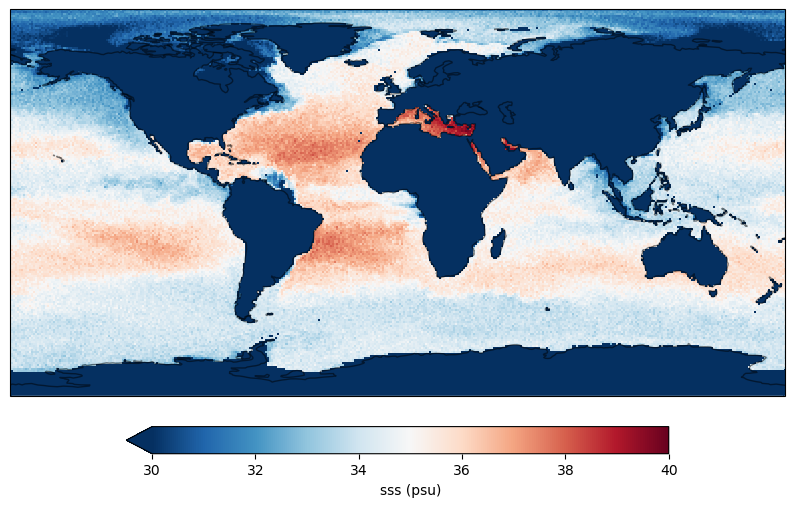

In [13]:
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs

channel = 13
field = xr.DataArray(inputs[0, :, :, channel],
                     dims = ["lat", "lon"],
                     coords = {"lat": xinputs.coords["lat"].values,
                               "lon": xinputs.coords["lon"].values})

fig, ax = plt.subplots(1, 1, figsize=(10,8), subplot_kw=dict(projection=ccrs.PlateCarree()))
kwargs = {"cbar_kwargs":{"orientation": "horizontal", "shrink":0.7, "label":"sss (psu)", "pad":0.05}, 
          "robust":True, "cmap":"RdBu_r", "vmin":30, "vmax":40,}
field.plot(ax=ax, **kwargs)
ax.coastlines(alpha=0.5)
plt.savefig("figures/sea_surface_salinity_snapshot_with_noise.png", dpi=300)
plt.show()